In [ ]:
# D - Research Figures

#This notebook creates the final polished figures for the research paper / presentation.

## Figures  included
#Compound-wise lap time comparison
#Tyre degradation trend by compound
#Fuel load vs lap time
#Correlation heatmap
#Driver performance comparison
#Team performance comparison

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)

In [3]:
DATA_PATH = Path("../data/processed/master_dataset.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (11880, 14)


,Driver,Team,LapNumber,Compound,TyreLife,Stint,Position,TrackStatus,LapTimeSeconds,FuelLoadApprox,StintProgress,CompoundEncoded,FreshTyre,TyreAgeSquared
0,VER,Red Bull Racing,1.0,SOFT,4.0,1.0,2.0,1,83.186,0.984848,0.100,0,0,16.0
1,VER,Red Bull Racing,2.0,SOFT,5.0,1.0,2.0,1,79.871,0.969697,0.125,0,0,25.0
2,VER,Red Bull Racing,3.0,SOFT,6.0,1.0,1.0,1,79.364,0.954545,0.150,0,0,36.0
3,VER,Red Bull Racing,4.0,SOFT,7.0,1.0,1.0,1,80.766,0.939394,0.175,0,0,49.0
4,VER,Red Bull Racing,5.0,SOFT,8.0,1.0,1.0,1,80.827,0.924242,0.200,0,0,64.0


In [4]:
figures_path = Path("../outputs/figures")
figures_path.mkdir(parents=True, exist_ok=True)

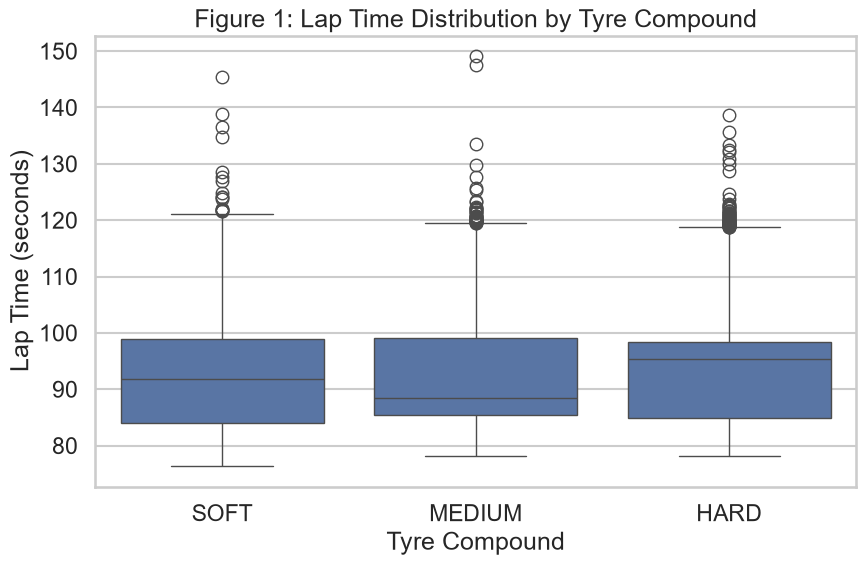

In [5]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x="Compound", y="LapTimeSeconds")
plt.title("Figure 1: Lap Time Distribution by Tyre Compound")
plt.xlabel("Tyre Compound")
plt.ylabel("Lap Time (seconds)")
plt.tight_layout()
plt.savefig(figures_path / "research_fig1_compound_laptime_boxplot.png", dpi=300)
plt.show()

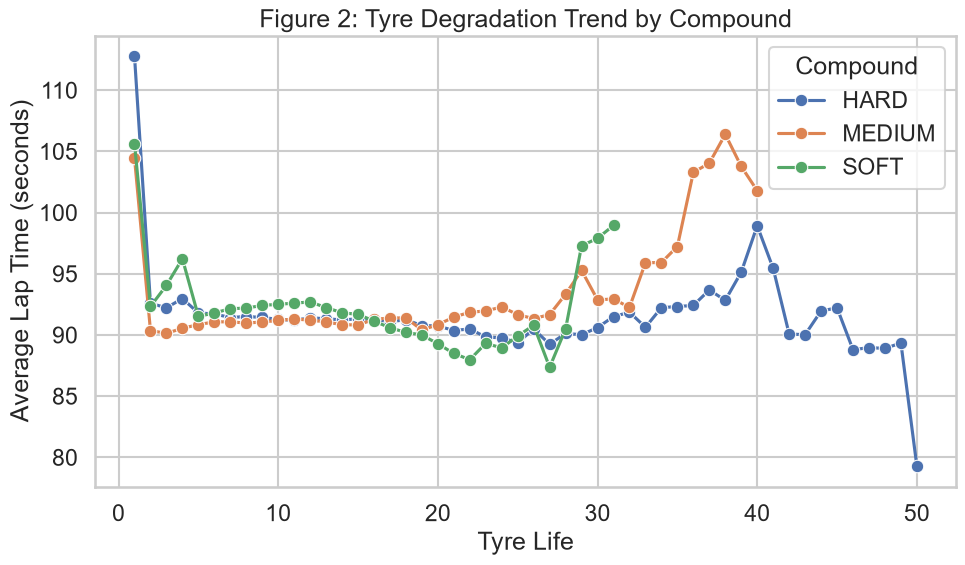

In [6]:
compound_deg = (
    df.groupby(["Compound", "TyreLife"])["LapTimeSeconds"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=compound_deg,
    x="TyreLife",
    y="LapTimeSeconds",
    hue="Compound",
    marker="o"
)
plt.title("Figure 2: Tyre Degradation Trend by Compound")
plt.xlabel("Tyre Life")
plt.ylabel("Average Lap Time (seconds)")
plt.tight_layout()
plt.savefig(figures_path / "research_fig2_tyre_degradation_by_compound.png", dpi=300)
plt.show()

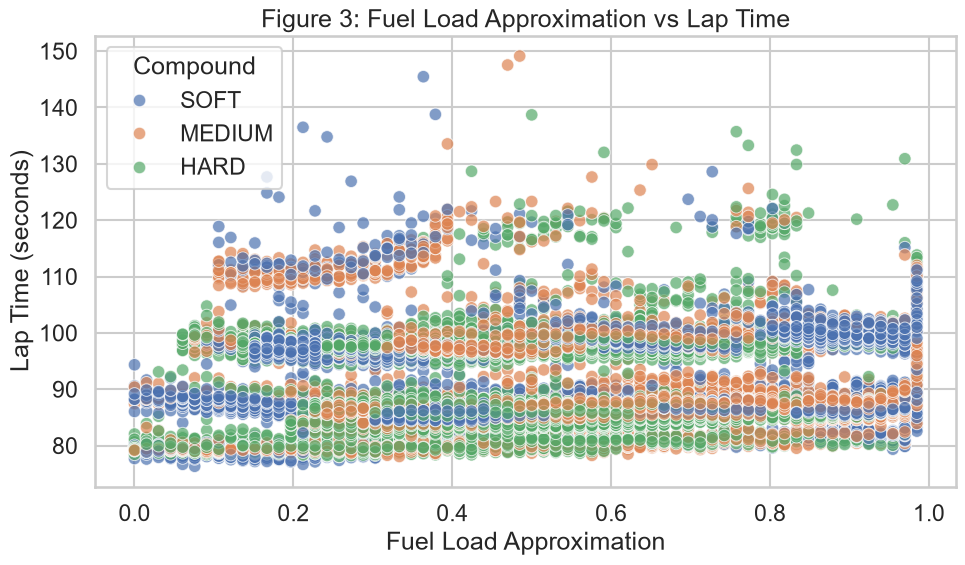

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="FuelLoadApprox",
    y="LapTimeSeconds",
    hue="Compound",
    alpha=0.7
)
plt.title("Figure 3: Fuel Load Approximation vs Lap Time")
plt.xlabel("Fuel Load Approximation")
plt.ylabel("Lap Time (seconds)")
plt.tight_layout()
plt.savefig(figures_path / "research_fig3_fuel_vs_laptime.png", dpi=300)
plt.show()

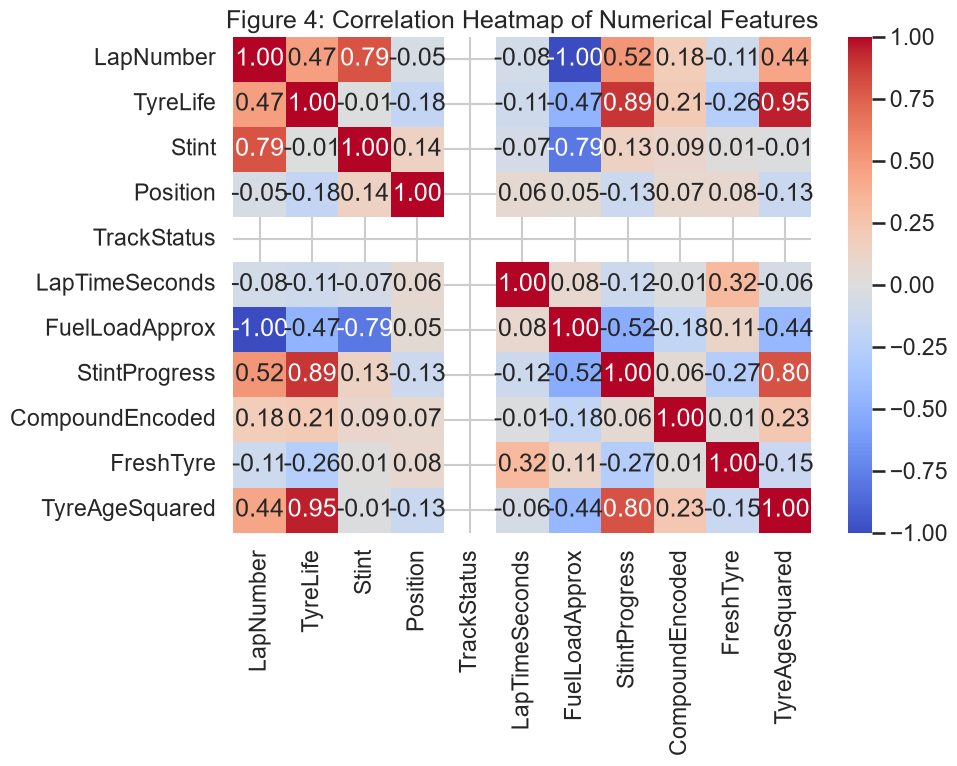

In [8]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Figure 4: Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig(figures_path / "research_fig4_correlation_heatmap.png", dpi=300)
plt.show()

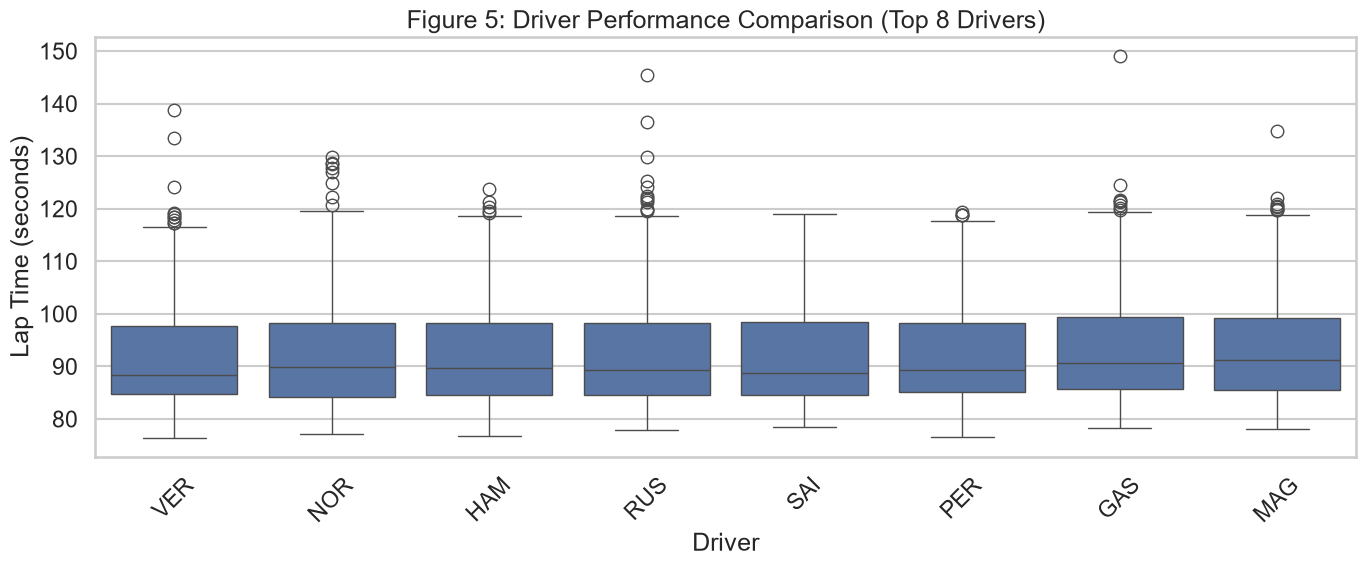

In [9]:
top_drivers = df["Driver"].value_counts().head(8).index
df_top_drivers = df[df["Driver"].isin(top_drivers)]

plt.figure(figsize=(14,6))
sns.boxplot(data=df_top_drivers, x="Driver", y="LapTimeSeconds")
plt.title("Figure 5: Driver Performance Comparison (Top 8 Drivers)")
plt.xlabel("Driver")
plt.ylabel("Lap Time (seconds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_path / "research_fig5_driver_comparison.png", dpi=300)
plt.show()

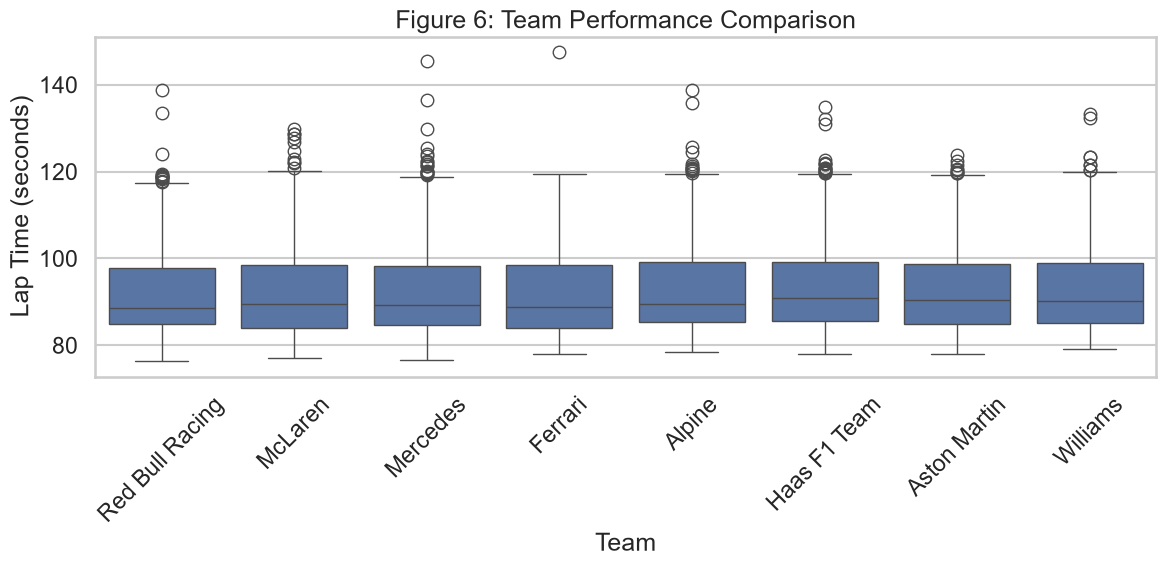

In [10]:
top_teams = df["Team"].value_counts().head(8).index
df_top_teams = df[df["Team"].isin(top_teams)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_teams, x="Team", y="LapTimeSeconds")
plt.title("Figure 6: Team Performance Comparison")
plt.xlabel("Team")
plt.ylabel("Lap Time (seconds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_path / "research_fig6_team_comparison.png", dpi=300)
plt.show()

In [11]:
print("Research figure notebook completed.")
print("Figures saved in:", figures_path)

research_figures = [
    "research_fig1_compound_laptime_boxplot.png",
    "research_fig2_tyre_degradation_by_compound.png",
    "research_fig3_fuel_vs_laptime.png",
    "research_fig4_correlation_heatmap.png",
    "research_fig5_driver_comparison.png",
    "research_fig6_team_comparison.png"
]

print("\nGenerated research figures:")
for fig in research_figures:
    print("-", fig)

Research figure notebook completed.
Figures saved in: ..\outputs\figures

Generated research figures:
- research_fig1_compound_laptime_boxplot.png
- research_fig2_tyre_degradation_by_compound.png
- research_fig3_fuel_vs_laptime.png
- research_fig4_correlation_heatmap.png
- research_fig5_driver_comparison.png
- research_fig6_team_comparison.png
